# Coarse-Resolution Re-Evaluation of the Sentinel-1 Model

**Purpose:** test whether the weak fine-scale reconstruction seen in `04_train_s1_with_tessa_baseline.ipynb`'s qualitative plots (real large-scale structure recovered, but fine dendritic/branching detail lost) is explained by Sentinel-1's native ~10m resolution being physically unable to carry sub-decameter detail -- rather than a model/training failure.

**This notebook is read-only with respect to your existing work**: it only *loads* the already-trained checkpoint (`s1_{REGION}_tessa_unet_best.pth`) and the same validation split used during training, runs evaluation, and writes its own separate output files. It does not modify, retrain, or overwrite anything from notebook 04.

**Method:** downsample both ground-truth and predicted LiDAR patches from 256x256 (1m/pixel) down to roughly 26x26 (via average pooling, factor 10x) -- matching the actual pixel count of the native Sentinel-1 window before it was bilinearly upsampled to fit the model's target size. Recompute RMSE/ZNCC/JSD at this coarse scale and compare against the original full-resolution metrics. If the coarse-scale metrics improve substantially (especially ZNCC), that's quantitative evidence the model recovers real structure at Sentinel-1's own native scale, with degradation below that scale being an information limit rather than a model failure.

## 1. Imports

In [1]:
import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio

assert torch.cuda.is_available(), 'CUDA is required. Run this notebook on the GPU environment.'
DEVICE = torch.device('cuda')
print('GPU:', torch.cuda.get_device_name(0))

GPU: NVIDIA GeForce RTX 4070 Ti SUPER


## 2. Configuration

**Must exactly match the config used in `04_train_s1_with_tessa_baseline.ipynb`** for the run you want to evaluate (paths, `CONTEXT_K`, `SEED`, `VAL_FRACTION`) -- this is what guarantees we reconstruct the identical validation split and load the matching checkpoint. Currently set to match the `s1_patches_tuk_michel_provided` run.

In [2]:
WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
TESSA_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche/tessa_baseline')
REGION = 'tuk'
LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_michel_provided'
CHECKPOINT_DIR = WORKING_REPO / 'checkpoints'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONTEXT_K = 3
TARGET_HW = (256, 256)
BATCH_SIZE = 8
TIMESTEPS = 1000
VAL_FRACTION = 0.15
SEED = 42
NOISE_SCHEDULE = 'linear'
ATTENTION_VARIANT = 'default'

POOL_SIZE = 10  # 256 / 10 ~= 26, matching Sentinel-1's native window size

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

## 3. Import Tessa's baseline implementation

In [3]:
sys.path.insert(0, str(TESSA_REPO))
from src.model.unet import ConditionalUNet
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddim
from src.utils.recon_metrics import rmse, bias, sigma_error, normal_angle_error, average_jsd_multiscale, log_psd_rmse, zncc

## 4. Dataset adapter (identical to notebook 04)

In [4]:
class LidarS1Dataset(Dataset):
    def __init__(self, s1_dir, lidar_dir, patch_ids, context_k=3, target_hw=(256, 256), train=False):
        self.s1_dir = Path(s1_dir)
        self.lidar_dir = Path(lidar_dir)
        self.patch_ids = list(patch_ids)
        self.context_k = context_k
        self.target_hw = target_hw
        self.train = train

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, index):
        patch_id = self.patch_ids[index]
        lidar_path = self.lidar_dir / f'lidar_patch_{patch_id}.tif'
        s1_path = self.s1_dir / f's1_patch_{patch_id}'
        with rasterio.open(lidar_path) as src:
            raw = src.read().astype(np.float32)
        target = raw[0]
        mask = (raw[1] > 0.5) if raw.shape[0] > 1 else np.isfinite(target)
        target = np.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0)
        valid_count = max(1, int(mask.sum()))
        patch_mean = float(target[mask].sum() / valid_count)
        target = (target - patch_mean) * mask

        times = sorted(s1_path.glob('t*.tif'))[:self.context_k]
        if len(times) < self.context_k:
            raise RuntimeError(f'{s1_path} has fewer than {self.context_k} Sentinel-1 times')
        views = []
        for time_path in times:
            with rasterio.open(time_path) as src:
                sar = src.read()[:2].astype(np.float32)
            sar = np.nan_to_num(sar, nan=0.0, posinf=0.0, neginf=0.0)
            sar = np.maximum(sar, 1e-12)
            sar = 10.0 * np.log10(sar)
            sar_tensor = torch.from_numpy(sar).unsqueeze(0)
            sar_tensor = F.interpolate(sar_tensor, size=self.target_hw, mode='bilinear', align_corners=False).squeeze(0)
            sar_tensor = sar_tensor.repeat(2, 1, 1)
            views.append(sar_tensor)
        condition = torch.cat(views, dim=0)
        attrs = torch.zeros(8 * self.context_k, dtype=torch.float32)
        return {'lidar': torch.from_numpy(target).unsqueeze(0).float(), 'mask': torch.from_numpy(mask), 's1': condition.float(), 'attrs': attrs, 'patch_mean': torch.tensor(patch_mean), 'patch_id': patch_id}

## 5. Rebuild the identical validation split

Same pairing, same seed, same shuffle as notebook 04 -- reconstructs the exact same held-out validation set, none of which the loaded checkpoint was trained on.

In [5]:
lidar_ids = {p.stem.split('_')[-1] for p in LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)
assert paired_ids, 'No paired Sentinel-1/LiDAR patches found.'
random.Random(SEED).shuffle(paired_ids)
n_val = max(1, int(len(paired_ids) * VAL_FRACTION))
val_ids, train_ids = paired_ids[:n_val], paired_ids[n_val:]
print(f'Paired: {len(paired_ids)} | train: {len(train_ids)} | validation: {len(val_ids)}')

val_dataset = LidarS1Dataset(S1_DIR, LIDAR_DIR, val_ids, CONTEXT_K, TARGET_HW, train=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Paired: 1676 | train: 1425 | validation: 251


## 6. Load the trained model and checkpoint

In [6]:
model = ConditionalUNet(in_channels=1, cond_channels=4 * CONTEXT_K, attr_dim=8 * CONTEXT_K, base_channels=128, embed_dim=256, unet_depth=4, attention_variant=ATTENTION_VARIANT, cond_k=CONTEXT_K).to(DEVICE)
scheduler = (LinearDiffusionScheduler(TIMESTEPS, device=DEVICE) if NOISE_SCHEDULE == 'linear' else CosineDiffusionScheduler(TIMESTEPS, device=DEVICE))

best_path = CHECKPOINT_DIR / f's1_{REGION}_tessa_unet_best.pth'
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('Loaded checkpoint from epoch', checkpoint.get('epoch'), 'val_loss', checkpoint.get('val_loss'))

Loaded checkpoint from epoch 83 val_loss 0.012679188075708225


## 7. Run evaluation, keeping every patch's full prediction array

Same DDIM sampling as notebook 04's evaluation cell, but this time storing the full GT/Pred/mask arrays for **every** validation patch (not just a handful), since the coarse-scale comparison needs the whole validation set to be statistically meaningful. Expect the same ~5-6 minute runtime as before.

In [7]:
sampler = p_sample_loop_ddim
fine_rows = []
all_patches = []
with torch.no_grad():
    for batch in val_loader:
        target = batch['lidar'].to(DEVICE)
        condition = batch['s1'].to(DEVICE)
        attrs = batch['attrs'].to(DEVICE)
        mask = batch['mask'].to(DEVICE).bool()
        prediction = sampler(model, scheduler, target.shape, condition, attrs, DEVICE)
        means = batch['patch_mean'].to(DEVICE).view(-1, 1, 1, 1)
        gt_absolute = target + means
        pred_absolute = prediction + means
        for i, patch_id in enumerate(batch['patch_id']):
            gt_i, pred_i, mask_i = gt_absolute[i], pred_absolute[i], mask[i]
            fine_rows.append({
                'patch_id': patch_id,
                'rmse_m': float(rmse(gt_i, pred_i, mask_i).item()),
                'bias_m': float(bias(gt_i, pred_i, mask_i).item()),
                'sigma_error_pct': float(sigma_error(gt_i, pred_i, mask_i).item()),
                'normal_angle_error_deg': float(normal_angle_error(gt_i, pred_i, mask_i, pixel_size=1.0, degrees=True).item()),
                'jsd': float(average_jsd_multiscale(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
                'psd_rmse': float(log_psd_rmse(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
                'zncc': float(zncc(gt_i, pred_i, mask_i).item()),
            })
            all_patches.append({
                'patch_id': patch_id,
                'gt': gt_i.squeeze().cpu().numpy(),
                'pred': pred_i.squeeze().cpu().numpy(),
                'mask': mask_i.squeeze().cpu().numpy(),
            })

df_fine = pd.DataFrame(fine_rows)
print(f'Evaluated {len(df_fine)} validation patches at full (256x256) resolution')
print(df_fine[['rmse_m', 'bias_m', 'sigma_error_pct', 'normal_angle_error_deg', 'jsd', 'psd_rmse', 'zncc']].mean())

Evaluated 251 validation patches at full (256x256) resolution
rmse_m                     0.188036
bias_m                    -0.006823
sigma_error_pct           31.155850
normal_angle_error_deg     1.800763
jsd                        0.136147
psd_rmse                   2.076127
zncc                       0.182772
dtype: float64


## 8. Coarse-scale re-evaluation

Average-pool GT and Pred down by `POOL_SIZE` (10x -> ~26x26, matching Sentinel-1's native window before upsampling) and recompute the same metrics. Compare directly against the full-resolution means above.

In [8]:
coarse_rows = []
for p in all_patches:
    gt_t = torch.from_numpy(p['gt']).unsqueeze(0).unsqueeze(0)
    pred_t = torch.from_numpy(p['pred']).unsqueeze(0).unsqueeze(0)
    mask_t = torch.from_numpy(p['mask'].astype(np.float32)).unsqueeze(0).unsqueeze(0)

    gt_coarse = F.avg_pool2d(gt_t, POOL_SIZE).squeeze()
    pred_coarse = F.avg_pool2d(pred_t, POOL_SIZE).squeeze()
    mask_coarse = (F.avg_pool2d(mask_t, POOL_SIZE).squeeze() > 0.5)

    if mask_coarse.sum() < 2:
        continue

    coarse_rows.append({
        'patch_id': p['patch_id'],
        'rmse_m_coarse': float(rmse(gt_coarse, pred_coarse, mask_coarse).item()),
        'zncc_coarse': float(zncc(gt_coarse, pred_coarse, mask_coarse).item()),
        'jsd_coarse': float(average_jsd_multiscale(gt_coarse, pred_coarse, pixel_size=10.0, mask=mask_coarse).item()),
    })

df_coarse = pd.DataFrame(coarse_rows)
print(f'Coarse-scale re-evaluation over {len(df_coarse)} patches (pooled {POOL_SIZE}x{POOL_SIZE} -> ~26x26, matching S1 native resolution):')
print(df_coarse[['rmse_m_coarse', 'zncc_coarse', 'jsd_coarse']].mean())
print()
print('Full-resolution means, for direct comparison:')
print(df_fine[['rmse_m', 'zncc', 'jsd']].mean())

comparison_path = OUTPUT_DIR / 's1_coarse_vs_fine_comparison.json'
with comparison_path.open('w') as handle:
    json.dump({
        'fine_resolution': df_fine[['rmse_m', 'zncc', 'jsd']].mean().to_dict(),
        'coarse_resolution': df_coarse[['rmse_m_coarse', 'zncc_coarse', 'jsd_coarse']].mean().to_dict(),
        'pool_size': POOL_SIZE,
        'n_patches': len(df_coarse),
    }, handle, indent=2)
print('Saved comparison summary to:', comparison_path)

Coarse-scale re-evaluation over 251 patches (pooled 10x10 -> ~26x26, matching S1 native resolution):
rmse_m_coarse    0.165280
zncc_coarse      0.212075
jsd_coarse       0.245112
dtype: float64

Full-resolution means, for direct comparison:
rmse_m    0.188036
zncc      0.182772
jsd       0.136147
dtype: float64
Saved comparison summary to: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_coarse_vs_fine_comparison.json


## 9. Visual comparison

Side-by-side violin plots of ZNCC at full resolution vs. coarse resolution across all validation patches -- the clearest single figure for showing whether spatial correlation genuinely improves once fine detail below Sentinel-1's native scale is no longer being penalized.

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_coarse_vs_fine_violin.png


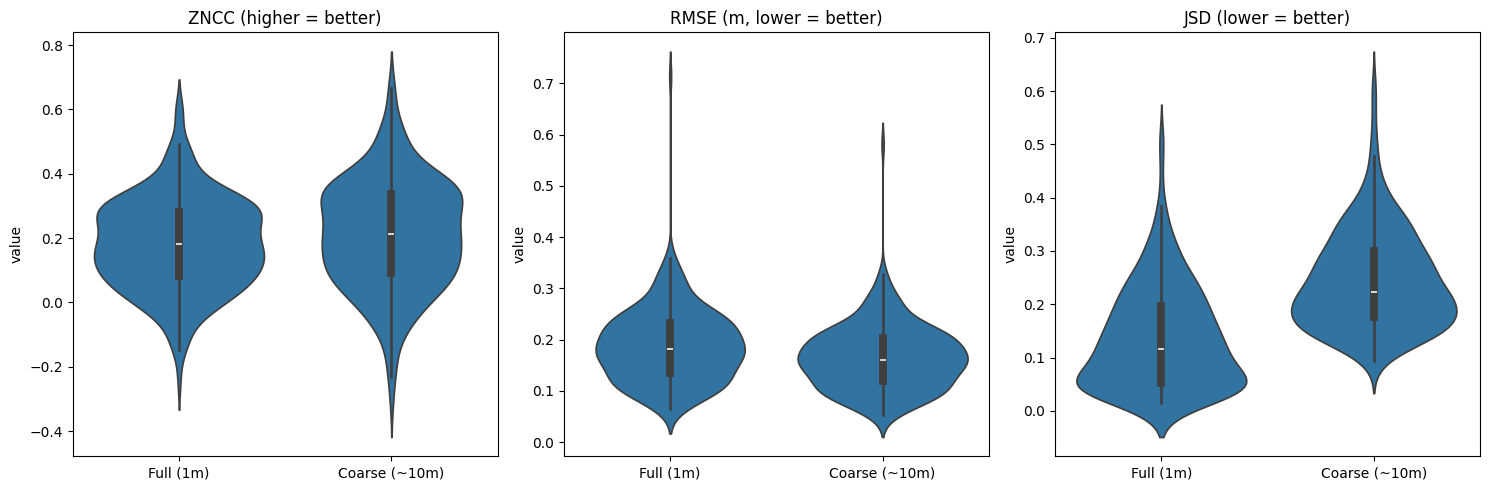

In [9]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

merged = df_fine.merge(df_coarse, on='patch_id')

for ax, (fine_col, coarse_col, title) in zip(axes, [
    ('zncc', 'zncc_coarse', 'ZNCC (higher = better)'),
    ('rmse_m', 'rmse_m_coarse', 'RMSE (m, lower = better)'),
    ('jsd', 'jsd_coarse', 'JSD (lower = better)'),
]):
    plot_df = pd.DataFrame({
        'value': pd.concat([merged[fine_col], merged[coarse_col]], ignore_index=True),
        'resolution': ['Full (1m)'] * len(merged) + ['Coarse (~10m)'] * len(merged),
    })
    sns.violinplot(data=plot_df, x='resolution', y='value', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 's1_coarse_vs_fine_violin.png', dpi=150, bbox_inches='tight')
print('Saved:', OUTPUT_DIR / 's1_coarse_vs_fine_violin.png')
plt.show()